# 1) Setup and Imports

**Goal**
Initialize runtime libraries and deterministic seeds for inference.

**What this section does**
Loads PyTorch/Waymo/plotting dependencies and sets reproducibility seed.

**Inputs**
- Notebook environment with model + Waymo dependencies.

**Output / interpretation**
- Stable inference runtime context.


### Execution Note

Outputs were cleared during presentation cleanup. Run sections 4-7 to regenerate rollout metrics, animation, and report figures.


In [12]:
import torch
import torch.nn as nn
from matplotlib import rc
from torch.utils.data import DataLoader, IterableDataset
import math
import os
import random
import matplotlib.pyplot as plt
import numpy as np
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from waymo_open_dataset.protos import scenario_pb2
from waymo_open_dataset.protos import sim_agents_submission_pb2
from waymo_open_dataset.utils import trajectory_utils
from waymo_open_dataset.utils.sim_agents import submission_specs
from waymo_open_dataset.utils.sim_agents import visualizations
from waymo_open_dataset.wdl_limited.sim_agents_metrics import metric_features

rc("animation", html="jshtml")
SEED = 24
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything(SEED)

# 2) Configuration and Constants

**Goal**
Declare rollout/model constants used throughout inference.

**What this section does**
Defines geometry dimensions, diffusion settings, and data source paths.

**Inputs**
- Project checkpoint and Waymo validation source.

**Output / interpretation**
- Single place to tune inference behavior.


In [13]:
TYPE_VEHICLE = 1
TYPE_PEDESTRIAN = 2
TYPE_CYCLIST = 3

HISTORY_STEPS = 11
FUTURE_STEPS = 80
NEIGHBORS_K = 6

HIST_DIM = 13
NBR_DIM = 10
MAP_DIM = 5
STATIC_DIM = 7
TARGET_DIM = FUTURE_STEPS * 4
COND_DIM = 256

DIFFUSION_T = 200
DIFFUSION_SAMPLE_STEPS = 50
GUIDANCE_SCALE = 1.2
GUIDANCE_SWEEP = [1.0, 1.2, 1.5]
EMA_DECAY = 0.999
CFG_DROPOUT = 0.1
TRAJ_TOKEN_STEPS = 5

HIGH_SPEED_STEP_THRESHOLD = 2.6
HIGHWAY_GUIDANCE_SWEEP = [1.2, 1.5, 1.8]
HIGHWAY_SAMPLE_STEPS = 64
HIGHWAY_CLAMP_SCALE = 0.8

GCS_BASE = "gs://waymo_open_dataset_motion_v_1_3_1/uncompressed/scenario"
GCS_VAL_PATH = f"{GCS_BASE}/validation/"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"
print("Device:", DEVICE)


Device: cuda


# 3) Model Architecture Imports

**Goal**
Reuse training-consistent model/sampling code.

**What this section does**
Imports diffusion model classes and samplers from `notebooks_lib.diffusion_core`.

**Inputs**
- `notebooks_lib/diffusion_core.py`

**Output / interpretation**
- Architecture parity between training and inference notebooks.


In [ ]:
from notebooks_lib.diffusion_core import (
    ConditionEncoder,
    ChunkDiffusionModel,
    make_cosine_schedule,
    zero_condition_like,
    _build_init_token_prior,
    sample_future_chunk,
)


# 4) Load Model Checkpoint

**Goal**
Restore trained weights and normalization/token artifacts.

**What this section does**
Loads checkpoint state into model + EMA model and builds diffusion config.

**Inputs**
- `chunk_diffusion_pytorch_only.pt`

**Output / interpretation**
- Ready-to-sample inference model state.


In [15]:
checkpoint_path = "chunk_diffusion_pytorch_only.pt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

position_tokens = checkpoint.get("position_tokens", None)
trajectory_tokens = checkpoint.get("trajectory_tokens", None)
pos_vocab_size = int(position_tokens.shape[0]) if isinstance(position_tokens, torch.Tensor) else 0
traj_vocab_size = int(trajectory_tokens.shape[0]) if isinstance(trajectory_tokens, torch.Tensor) else 0

model = ChunkDiffusionModel(pos_vocab_size=pos_vocab_size, traj_vocab_size=traj_vocab_size).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.eval()

ema_model = ChunkDiffusionModel(pos_vocab_size=pos_vocab_size, traj_vocab_size=traj_vocab_size).to(DEVICE)
ema_model.load_state_dict(checkpoint["ema_state_dict"], strict=False)
ema_model.eval()

target_mean = checkpoint["target_mean"].to(DEVICE)
target_std = checkpoint["target_std"].to(DEVICE)
schedule = make_cosine_schedule(DIFFUSION_T, DEVICE)

DIFFUSION_CFG = {
    "schedule": schedule,
    "sample_steps": DIFFUSION_SAMPLE_STEPS,
    "guidance_scale": GUIDANCE_SCALE,
    "target_mean": target_mean,
    "target_std": target_std,
    "ema_model": ema_model,
    "position_tokens": position_tokens.to(DEVICE) if isinstance(position_tokens, torch.Tensor) else None,
    "trajectory_tokens": trajectory_tokens.to(DEVICE) if isinstance(trajectory_tokens, torch.Tensor) else None,
}
print("Model loaded successfully.")
print("Token priors available:", DIFFUSION_CFG["position_tokens"] is not None and DIFFUSION_CFG["trajectory_tokens"] is not None)


Model loaded successfully.
Token priors available: True


# 5) Load and Process Scenario Data

**Goal**
Fetch one validation scenario and build model input features.

**What this section does**
Downloads/loads TFRecord, decodes scenario proto, and prepares rollout tensors.

**Inputs**
- Validation TFRecord selection (`FILE_INDEX`, `SCENARIO_INDEX`).

**Output / interpretation**
- `scene_features` and `scenario` objects for rollout.


In [16]:
from notebooks_lib.waymo_features import (
    wrap_angle,
    to_local,
    to_world,
    object_type_one_hot,
    extract_map_arrays,
    compute_map_context,
    get_sim_agent_trajectories,
    build_scene_rollout_features,
)


In [17]:
from notebooks_lib.io_utils import ensure_local_tfrecord, list_validation_tfrecords

challenge_type = submission_specs.ChallengeType.SCENARIO_GEN
submission_config = submission_specs.get_submission_config(challenge_type)

FILE_INDEX = 0      # Change to inspect a different validation TFRecord file
SCENARIO_INDEX = 9  # Change to inspect a different scenario within that file

val_files = list_validation_tfrecords(gcs_val_path=GCS_VAL_PATH, refresh=False)
if len(val_files) == 0:
    raise RuntimeError("No validation files found at configured GCS path.")

target_file = val_files[FILE_INDEX]
local_temp = ensure_local_tfrecord(target_file, cache_dir="./waymo_val_cache", force_refresh=False, verbose=True)

dataset = tf.data.TFRecordDataset([local_temp])
iterator = iter(dataset.as_numpy_iterator())
for _ in range(SCENARIO_INDEX):
    next(iterator)

bytes_example = next(iterator)
scenario = scenario_pb2.Scenario.FromString(bytes_example)
scene_features = build_scene_rollout_features(scenario, challenge_type, submission_config)
scene_features["num_rollouts"] = 1

print(f"Loaded scenario: {scenario.scenario_id} | num_rollouts={scene_features['num_rollouts']}")


Using cached TFRecord: ./waymo_val_cache/validation.tfrecord-00000-of-00150
Loaded scenario: c95a61d1861f429a | num_rollouts=1


# 6) Run Generative Inference and Safety Post-Processing

**Goal**
Generate future trajectories and evaluate post-process behavior.

**What this section does**
Uses shared rollout/postprocess helpers from `notebooks_lib.waymo_features`, runs inference, and prints core metrics.

**Inputs**
- Loaded model + scene features + inference/physics configs.

**Output / interpretation**
- Simulated rollout states and safety/realism metrics.


In [18]:
import time
from notebooks_lib import waymo_features as wf

# Keep module-level config synchronized with this notebook.
wf.DIFFUSION_CFG = DIFFUSION_CFG
wf.DEVICE = DEVICE
wf.DIFFUSION_SAMPLE_STEPS = DIFFUSION_SAMPLE_STEPS
wf.GUIDANCE_SWEEP = GUIDANCE_SWEEP
wf.HISTORY_STEPS = HISTORY_STEPS
wf.FUTURE_STEPS = FUTURE_STEPS
wf.NEIGHBORS_K = NEIGHBORS_K

# Local aliases for downstream cells.
predict_challenge_80 = wf.predict_challenge_80
compute_postprocess_metrics = wf.compute_postprocess_metrics
run_postprocess_ablation = wf.run_postprocess_ablation
rollout_cv_baseline = wf.rollout_cv_baseline
compute_error_metrics = wf.compute_error_metrics
DEFAULT_INFERENCE_CFG = wf.DEFAULT_INFERENCE_CFG
DEFAULT_PHYSICS_CFG = wf.DEFAULT_PHYSICS_CFG


# Auto-load scenario context if section 5 was skipped in this session.
if "scene_features" not in globals() or "scenario" not in globals() or "submission_config" not in globals():
    from notebooks_lib.io_utils import ensure_local_tfrecord, list_validation_tfrecords

    challenge_type = submission_specs.ChallengeType.SCENARIO_GEN
    submission_config = submission_specs.get_submission_config(challenge_type)

    file_idx = int(globals().get("FILE_INDEX", 0))
    scenario_idx = int(globals().get("SCENARIO_INDEX", 9))

    val_files = list_validation_tfrecords(gcs_val_path=GCS_VAL_PATH, refresh=False)
    if len(val_files) == 0:
        raise RuntimeError("No validation files found at configured GCS path.")

    target_file = val_files[file_idx]
    local_temp = ensure_local_tfrecord(target_file, cache_dir="./waymo_val_cache", force_refresh=False, verbose=True)

    dataset = tf.data.TFRecordDataset([local_temp])
    iterator = iter(dataset.as_numpy_iterator())
    for _ in range(scenario_idx):
        next(iterator)

    bytes_example = next(iterator)
    scenario = scenario_pb2.Scenario.FromString(bytes_example)
    scene_features = build_scene_rollout_features(scenario, challenge_type, submission_config)
    print(f"[Auto-load] Loaded scenario: {scenario.scenario_id}")
scene_features["num_rollouts"] = 1

inference_cfg_vis = {
    "guidance_values": (1.0, 1.2),
    "sample_steps": 40,
    "use_ema": True,
    "postprocess_mode": "bicycle",
    "use_history_speed_clamp": True,
    "use_road_bound": True,
    "use_light_repulsion": True,
    "dt": 0.1,
    "use_clamping": True,
    "use_guidance_sweep": True,
    "sanitize_prediction": True,
    "force_highway_mode": False,
}

physics_cfg_vis = {
    "veh_accel_min": -3.0,
    "veh_accel_max": 2.2,
    "veh_steer_limit": 0.45,
    "no_slip_lat_ratio": 0.02,
    "min_edge_clearance_m": 0.9,
    "lane_pull_gain": 0.08,
    "repulsion_max_push": 0.18,
}

_t0 = time.perf_counter()
my_simulated_states, chosen_guidance, guidance_scores, highway_mode, high_speed_frac = predict_challenge_80(
    model=model,
    scene_features=scene_features,
    current_idx=int(submission_config.current_time_index),
    inference_cfg=inference_cfg_vis,
    physics_cfg=physics_cfg_vis,
)
_elapsed = time.perf_counter() - _t0

_post_metrics = compute_postprocess_metrics(
    my_simulated_states,
    scene_features,
    current_idx=int(submission_config.current_time_index),
    dt=float(inference_cfg_vis["dt"]),
    physics_cfg=physics_cfg_vis,
)

print("Bicycle post-process rollout complete, state shape:", my_simulated_states.shape)
print("Chosen guidance:", chosen_guidance)
print("Guidance scores:", guidance_scores)
print("Highway mode:", highway_mode, "high_speed_frac:", round(high_speed_frac, 3))
print("Runtime (s):", round(_elapsed, 3))
print("Post-process metrics:", _post_metrics)

# Optional ablation (legacy vs bicycle_no_safety vs bicycle_full)
# _ablation = run_postprocess_ablation(
#     model=model,
#     scene_features=scene_features,
#     current_idx=int(submission_config.current_time_index),
#     use_ema=True,
# )


Bicycle post-process rollout complete, state shape: (1, 22, 91, 4)
Chosen guidance: 1.0
Guidance scores: {1.0: 9653.197265625, 1.2: 9057.4921875}
Highway mode: False high_speed_frac: 0.0
Runtime (s): 1.159
Post-process metrics: {'nan_count': 0, 'mean_vehicle_slip_ratio': 0.4305053226973914, 'offroad_violations': 23, 'collision_pairs': 0}


# 7) Visualize Predicted Trajectories

**Goal**
Inspect generated trajectories qualitatively and produce publishable figures.

**What this section does**
Renders animated rollout and static report figures using shared plotting helpers.

**Inputs**
- Predicted states, ground truth, and scene map context.

**Output / interpretation**
- Final visuals suitable for README/report inclusion.


Adjusted sample_index from 1 to 0 (available: 0..0)


ImportError: cannot import name 'save_animation_gif' from 'notebooks_lib.visualization' (/home/inzaghi/MATH461/notebooks_lib/visualization.py)

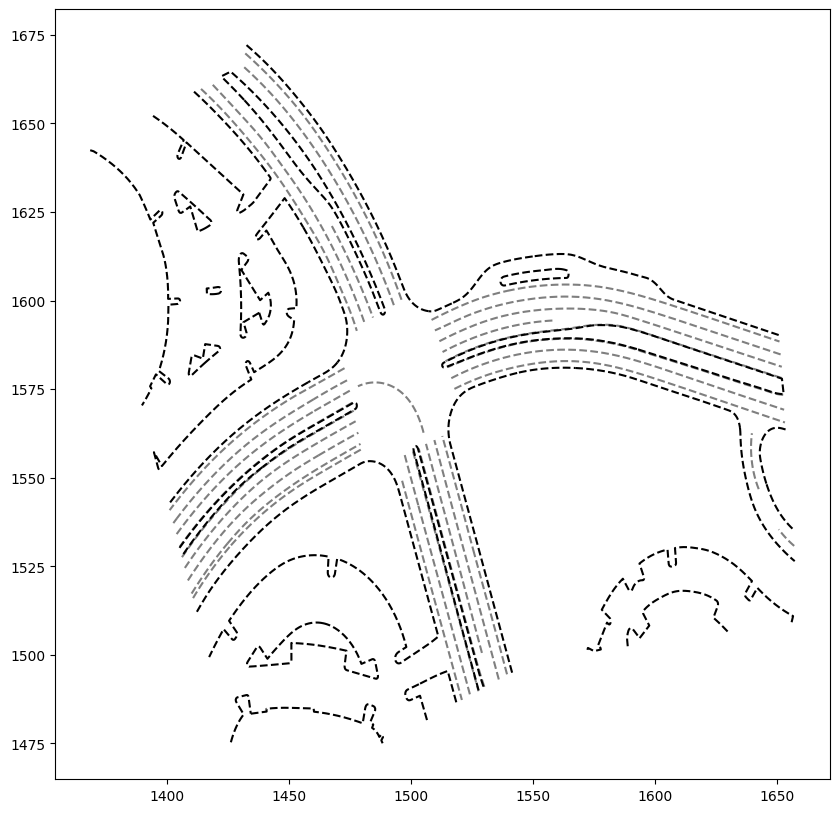

In [ ]:
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128

requested_sample_index = 1
max_sample_index = max(0, my_simulated_states.shape[0] - 1)
sample_index = int(np.clip(requested_sample_index, 0, max_sample_index))
if sample_index != requested_sample_index:
    print(f"Adjusted sample_index from {requested_sample_index} to {sample_index} (available: 0..{max_sample_index})")

num_objects = scene_features["valid"].shape[0]
n_steps = my_simulated_states.shape[2]
object_types = tf.convert_to_tensor(scene_features["object_type"], dtype=tf.int32)
color_indices = tf.cast(tf.tile(object_types[:, tf.newaxis], [1, n_steps]), dtype=tf.int32)

base_sizes = np.nan_to_num(scene_features["sizes"].copy(), nan=0.0, posinf=0.0, neginf=0.0)
simulated_sizes = np.zeros((my_simulated_states.shape[0], num_objects, n_steps, 3), dtype=np.float32)
orig_n_steps = base_sizes.shape[1]
simulated_sizes[:, :, :orig_n_steps, :] = base_sizes[None, ...]

for obj_idx in range(num_objects):
    valid_idx = np.flatnonzero(scene_features["valid"][obj_idx])
    if valid_idx.size == 0:
        continue
    last_idx = int(valid_idx[-1])
    simulated_sizes[:, obj_idx, orig_n_steps:, :] = base_sizes[obj_idx, last_idx:last_idx + 1, :]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
visualizations.add_map(ax, scenario)

from notebooks_lib.visualization import save_animation_gif

vis = visualizations.get_animated_states(
    fig,
    ax,
    scenario,
    my_simulated_states[sample_index, :, :, 0],
    my_simulated_states[sample_index, :, :, 1],
    my_simulated_states[sample_index, :, :, 3],
    length=simulated_sizes[sample_index, :, :, 0],
    width=simulated_sizes[sample_index, :, :, 1],
    color_idx=color_indices,
)
plt.close()

# Export GIF to ./figures
gif_path = save_animation_gif(vis, stem="fig0_rollout_animation", fps=10, dpi=120)
print(f"GIF path: {gif_path}")
vis


In [ ]:
from notebooks_lib.visualization import (
    PAPER_FIG_DIR,
    save_figure,
    select_agents_for_plot,
    plot_main_overlay,
    plot_keyframe_strip,
    compute_horizon_error_curve,
    plot_error_horizon_curves,
    plot_safety_bar,
    plot_runtime_pareto,
    plot_case_gallery,
)


Saved figure: figures/fig1_main_overlay.png and figures/fig1_main_overlay.pdf


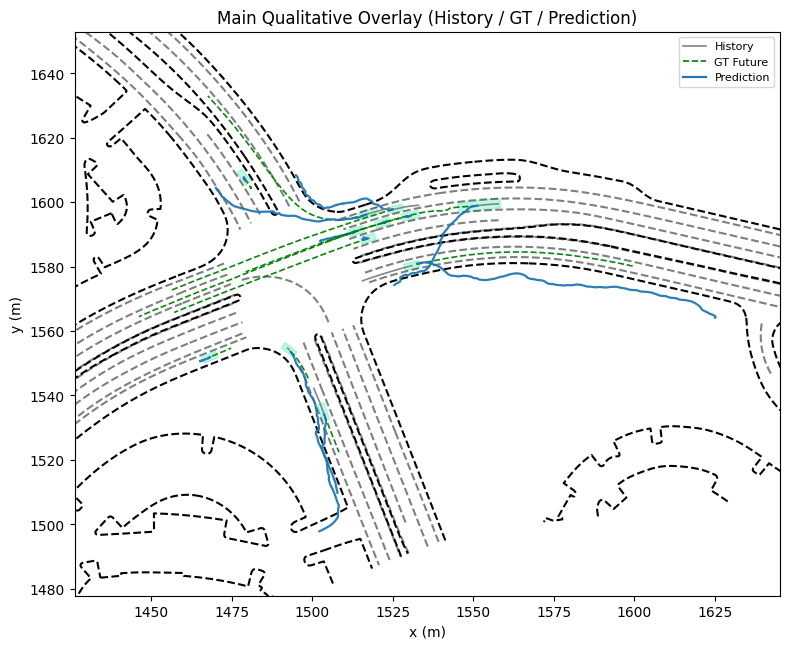

Saved figure: figures/fig2_keyframe_strip.png and figures/fig2_keyframe_strip.pdf


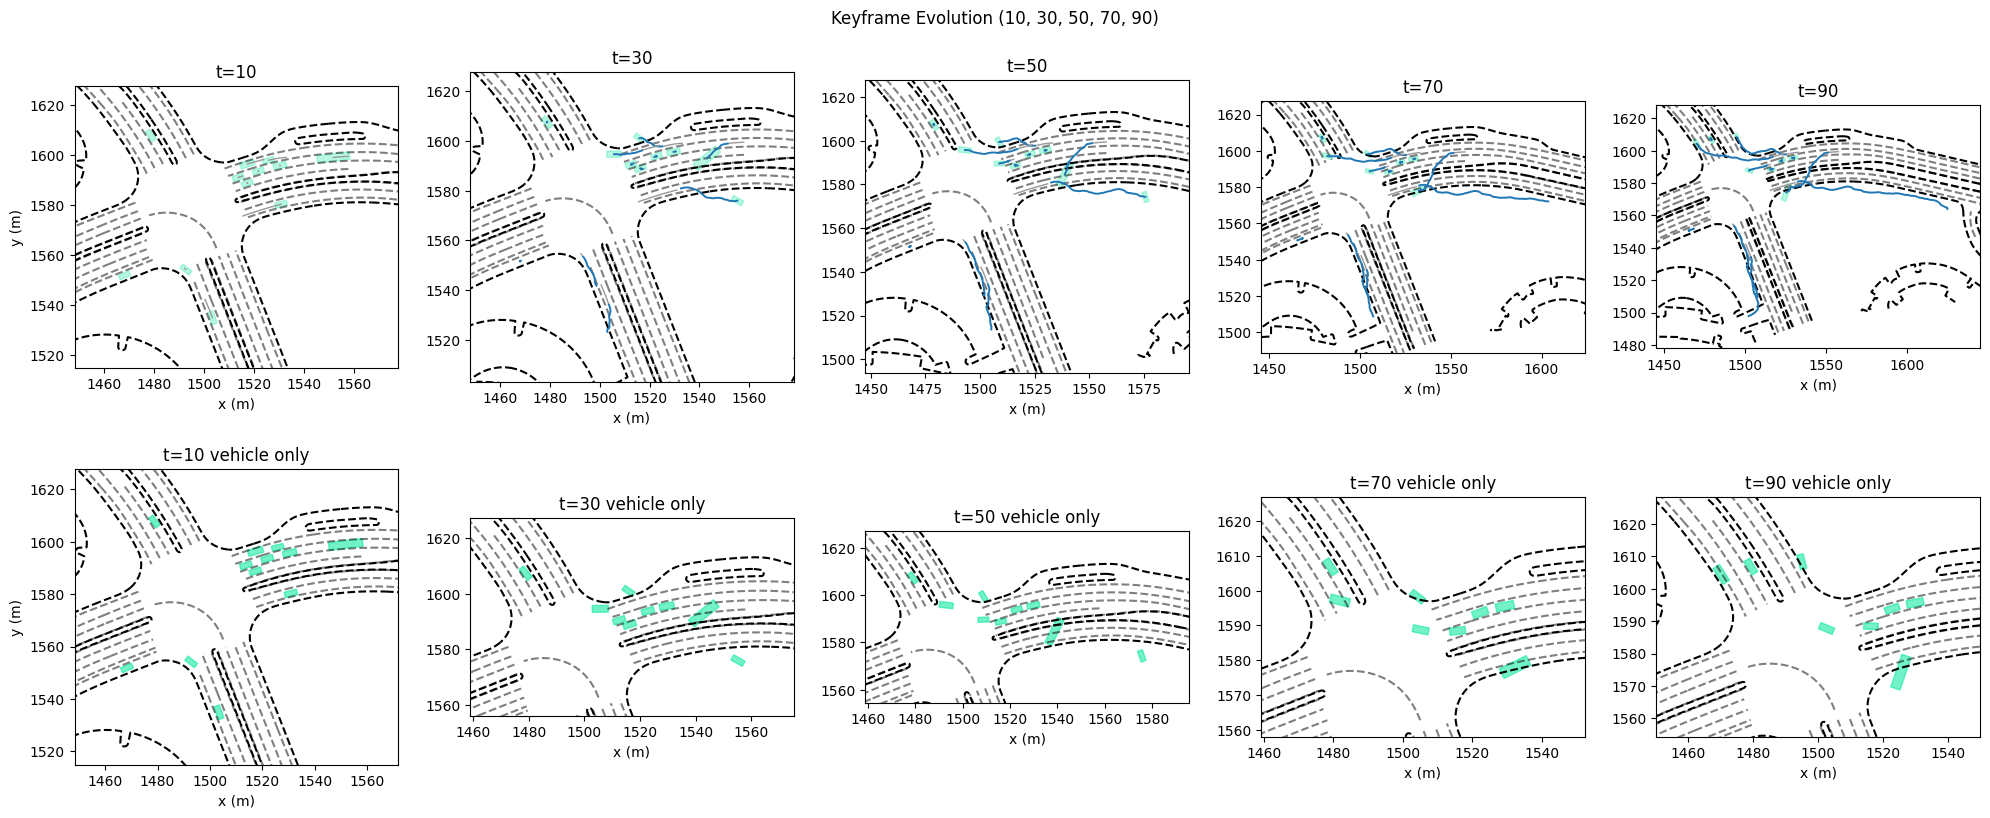

Running ablation for report plots...
Ablation summary:
legacy             | runtime=0.276s | offroad=153 | collisions=101 | slip=1.3156
bicycle_no_safety  | runtime=0.296s | offroad=53 | collisions=31 | slip=0.0515
bicycle_full       | runtime=0.886s | offroad=14 | collisions=5 | slip=0.4464
Saved figure: figures/fig3_error_horizon.png and figures/fig3_error_horizon.pdf


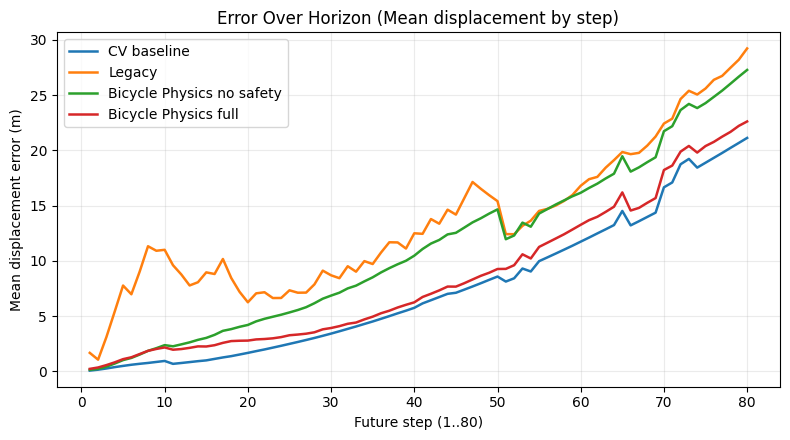

Saved figure: figures/fig4_safety_bars.png and figures/fig4_safety_bars.pdf


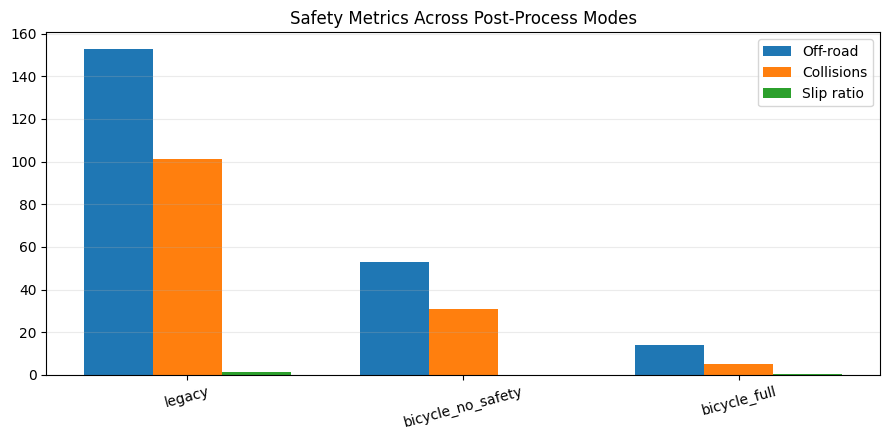

In [ ]:
# =====================
# Paper Figure Pipeline
# =====================
current_idx = int(submission_config.current_time_index)
scene_features["num_rollouts"] = 1

pred_main = my_simulated_states[0]
gt_states = scene_features["states"]
gt_valid = scene_features["valid"]

agent_ids = select_agents_for_plot(scene_features, current_idx=current_idx, max_agents=12, prefer_vehicles=True)

# Figure 1: Main qualitative overlay
fig_overlay = plot_main_overlay(
    scenario=scenario,
    scene_features=scene_features,
    pred_states=pred_main,
    current_idx=current_idx,
    agent_ids=agent_ids,
    title="Main Qualitative Overlay (History / GT / Prediction)",
)
save_figure(fig_overlay, "fig1_main_overlay")
plt.show()

# Figure 2: Keyframe strip
fig_keyframes = plot_keyframe_strip(
    scenario=scenario,
    scene_features=scene_features,
    pred_states=pred_main,
    current_idx=current_idx,
    agent_ids=agent_ids,
    keyframes=(10, 30, 50, 70, 90),
    title="Keyframe Evolution (10, 30, 50, 70, 90)"
)
save_figure(fig_keyframes, "fig2_keyframe_strip")
plt.show()

# Optional ablation compute (reuse if already present)
if "_ablation" in globals() and isinstance(_ablation, dict):
    ablation = _ablation
else:
    print("Running ablation for report plots...")
    ablation = run_postprocess_ablation(
        model=model,
        scene_features=scene_features,
        current_idx=current_idx,
        use_ema=True,
        physics_cfg=globals().get("physics_cfg_vis", None),
    )

# Build comparable predictions for error curves / gallery
inference_base = dict(globals().get("inference_cfg_vis", DEFAULT_INFERENCE_CFG))
physics_base = dict(globals().get("physics_cfg_vis", DEFAULT_PHYSICS_CFG))

cfg_legacy = dict(inference_base)
cfg_legacy.update({
    "postprocess_mode": "legacy",
    "use_road_bound": False,
    "use_light_repulsion": False,
    "use_guidance_sweep": False,
    "guidance_values": (1.0,),
    "fixed_guidance": 1.0,
})

cfg_no_safety = dict(inference_base)
cfg_no_safety.update({
    "postprocess_mode": "bicycle",
    "use_road_bound": False,
    "use_light_repulsion": False,
    "use_guidance_sweep": False,
    "guidance_values": (1.0,),
    "fixed_guidance": 1.0,
})

scene_features["num_rollouts"] = 1
sim_legacy, *_ = predict_challenge_80(
    model=model,
    scene_features=scene_features,
    current_idx=current_idx,
    inference_cfg=cfg_legacy,
    physics_cfg=physics_base,
)
sim_no_safety, *_ = predict_challenge_80(
    model=model,
    scene_features=scene_features,
    current_idx=current_idx,
    inference_cfg=cfg_no_safety,
    physics_cfg=physics_base,
)

sim_cv = rollout_cv_baseline(scene_features, current_idx=current_idx, horizon=FUTURE_STEPS, dt=inference_base["dt"])

pred_legacy = sim_legacy[0]
pred_no_safety = sim_no_safety[0]
pred_cv = sim_cv[0]

# Figure 3: Error-over-horizon
curves = {
    "CV baseline": compute_horizon_error_curve(pred_cv, gt_states, gt_valid, current_idx=current_idx),
    "Legacy": compute_horizon_error_curve(pred_legacy, gt_states, gt_valid, current_idx=current_idx),
    "Bicycle Physics no safety": compute_horizon_error_curve(pred_no_safety, gt_states, gt_valid, current_idx=current_idx),
    "Bicycle Physics full": compute_horizon_error_curve(pred_main, gt_states, gt_valid, current_idx=current_idx),
}
fig_err = plot_error_horizon_curves(curves, title="Error Over Horizon (Mean displacement by step)")
save_figure(fig_err, "fig3_error_horizon")
plt.show()

# Figure 4: Safety bar chart from ablation
fig_safety = plot_safety_bar(ablation, title="Safety Metrics Across Post-Process Modes")
save_figure(fig_safety, "fig4_safety_bars")
plt.show()

Saved figure: figures/fig6_case_gallery.png and figures/fig6_case_gallery.pdf


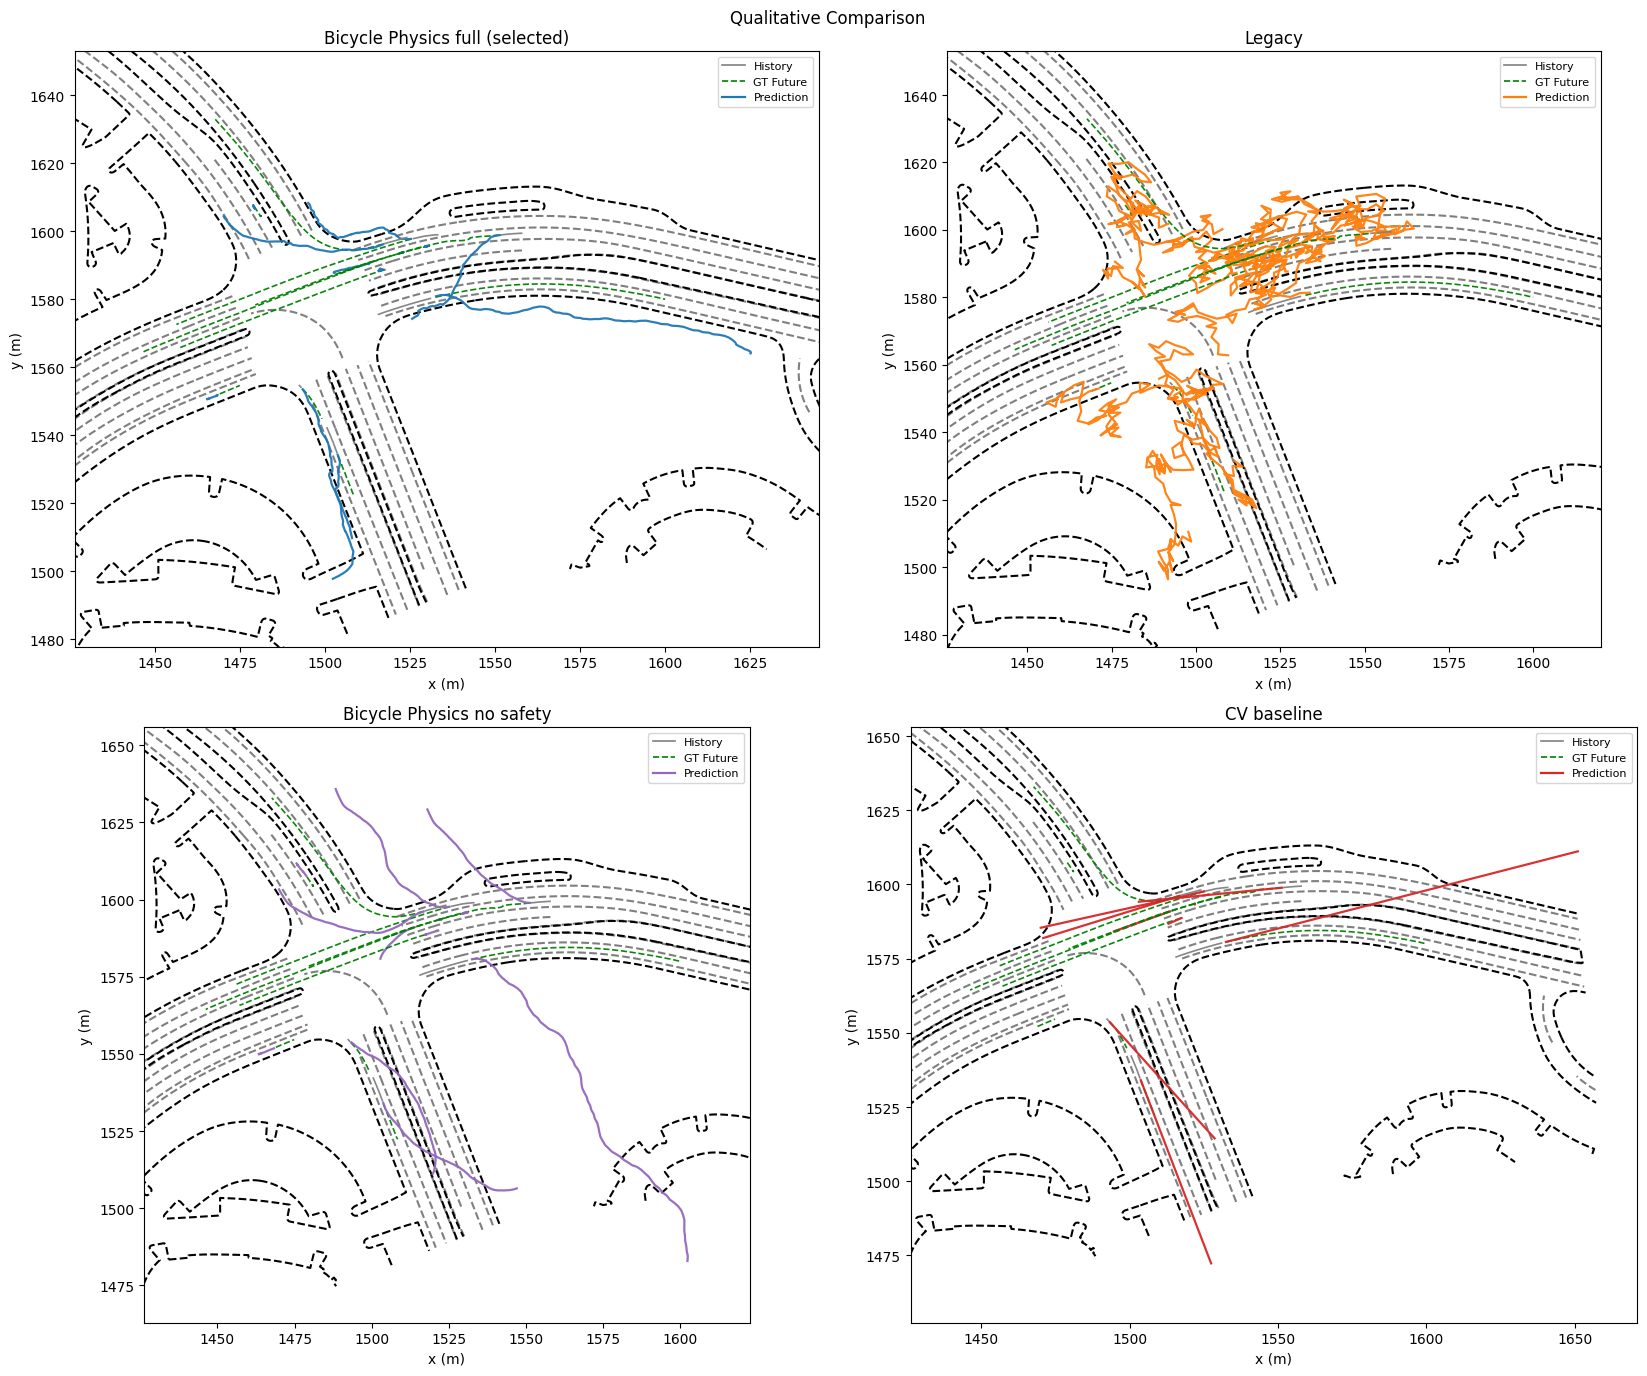

All paper figures saved under: /home/inzaghi/MATH461/figures


In [ ]:
# Figure 6: Case gallery (cool qualitative samples)
cases = [
    ("Bicycle Physics full (selected)", pred_main, "tab:blue"),
    ("Legacy", pred_legacy, "tab:orange"),
    ("Bicycle Physics no safety", pred_no_safety, "tab:purple"),
    ("CV baseline", pred_cv, "tab:red"),
]
fig_gallery = plot_case_gallery(
    scenario=scenario,
    scene_features=scene_features,
    current_idx=current_idx,
    agent_ids=agent_ids,
    cases=cases,
    title="Qualitative Comparison",
)
save_figure(fig_gallery, "fig6_case_gallery")
plt.show()


main_metrics = compute_postprocess_metrics(
    my_simulated_states,
    scene_features,
    current_idx=current_idx,
    dt=float(inference_base["dt"]),
    physics_cfg=physics_base,
)
main_errors = compute_error_metrics(
    pred_main,
    gt_states,
    gt_valid,
    current_idx=current_idx,
    horizon=FUTURE_STEPS,
)

print(f"All paper figures saved under: {PAPER_FIG_DIR.resolve()}")
